# 🚁 Drone Target Tracking Simulator

Interactive notebook for learning and experimenting with drone control algorithms.

## What This Simulates

```
┌──────────────┐     ┌────────────┐     ┌─────────────┐     ┌───────────┐
│   Target     │────▶│ Perception │────▶│ Controller  │────▶│   Drone   │
│  (moving)    │     │ (bearing,  │     │ (P, PID,    │     │ (position,│
│              │     │  range)    │     │  Pursuit)   │     │  heading) │
└──────────────┘     └────────────┘     └─────────────┘     └───────────┘
                                               │
                                               ▼
                                        ┌─────────────┐
                                        │ FCU Filter  │
                                        │ (vel/accel  │
                                        │  limits)    │
                                        └─────────────┘
```

## Setup

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt

# Enable interactive plots in notebooks
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

# Import our simulator
from drone_tracker import (
    Simulator, SimConfig,
    PController, PIDYawController, PurePursuitLike,
    make_controller,
    compare_runs, print_comparison,
)

print("✅ All imports successful!")

✅ All imports successful!


---
## 1️⃣ Quick Start: Run Your First Simulation

Let's run a simple simulation with default settings.

In [2]:
# Create a simulator with default config
sim = Simulator()

# Run with P controller tracking a circular target
result = sim.run(controller="p", scenario="circle")

# Show metrics
print(result.metrics)

Simulation Metrics:
  RMS Distance:      2.470 m
  Min Distance:      1.474 m
  Max Distance:      8.255 m
  Mean Distance:     1.999 m
  Time to Capture:   not captured
  Time in Capture:   0.00 s
  Control Energy (v):   0.974
  Control Energy (yaw): 0.043


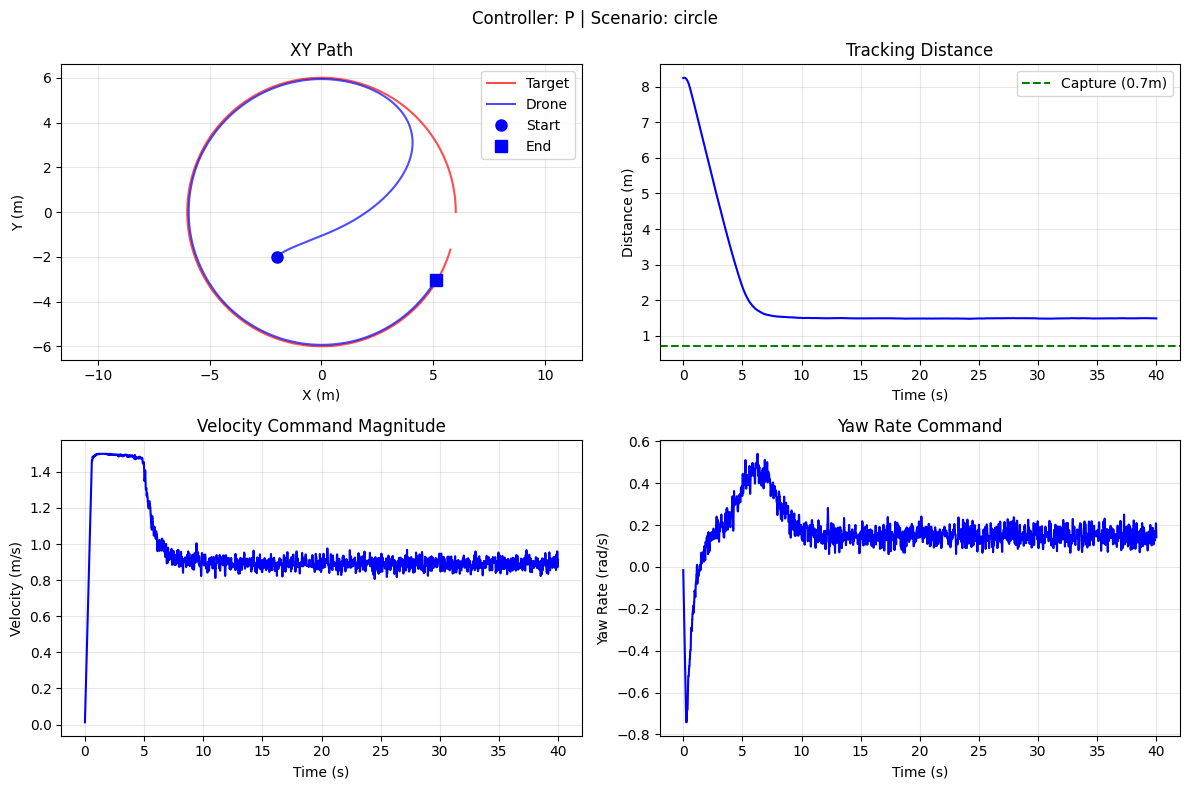

(<Figure size 1200x800 with 4 Axes>,
 array([[<Axes: title={'center': 'XY Path'}, xlabel='X (m)', ylabel='Y (m)'>,
         <Axes: title={'center': 'Tracking Distance'}, xlabel='Time (s)', ylabel='Distance (m)'>],
        [<Axes: title={'center': 'Velocity Command Magnitude'}, xlabel='Time (s)', ylabel='Velocity (m/s)'>,
         <Axes: title={'center': 'Yaw Rate Command'}, xlabel='Time (s)', ylabel='Yaw Rate (rad/s)'>]],
       dtype=object))

In [3]:
# Visualize the results
sim.plot(result)

### 📊 Understanding the Metrics

| Metric | What it means | Good values |
|--------|---------------|-------------|
| **RMS Distance** | Average tracking error | Lower is better (< 1m is good) |
| **Min Distance** | Closest approach | Shows if you ever got close |
| **Time to Capture** | Time to reach within capture radius | Faster = better acquisition |
| **Control Energy** | Sum of squared commands | Lower = smoother, more efficient |

---
## 2️⃣ Compare Controllers

Let's compare all three controllers on the same scenario.

In [4]:
# Run all three controllers
controllers = ["p", "pidyaw", "pursuit"]
results = {}

for ctrl_name in controllers:
    results[ctrl_name] = sim.run(controller=ctrl_name, scenario="circle")
    print(f"{ctrl_name.upper()}: RMS={results[ctrl_name].metrics.rms_dist:.3f}m, "
          f"Capture={results[ctrl_name].metrics.t_capture:.2f}s")

P: RMS=2.470m, Capture=infs
PIDYAW: RMS=2.311m, Capture=infs
PURSUIT: RMS=2.187m, Capture=infs


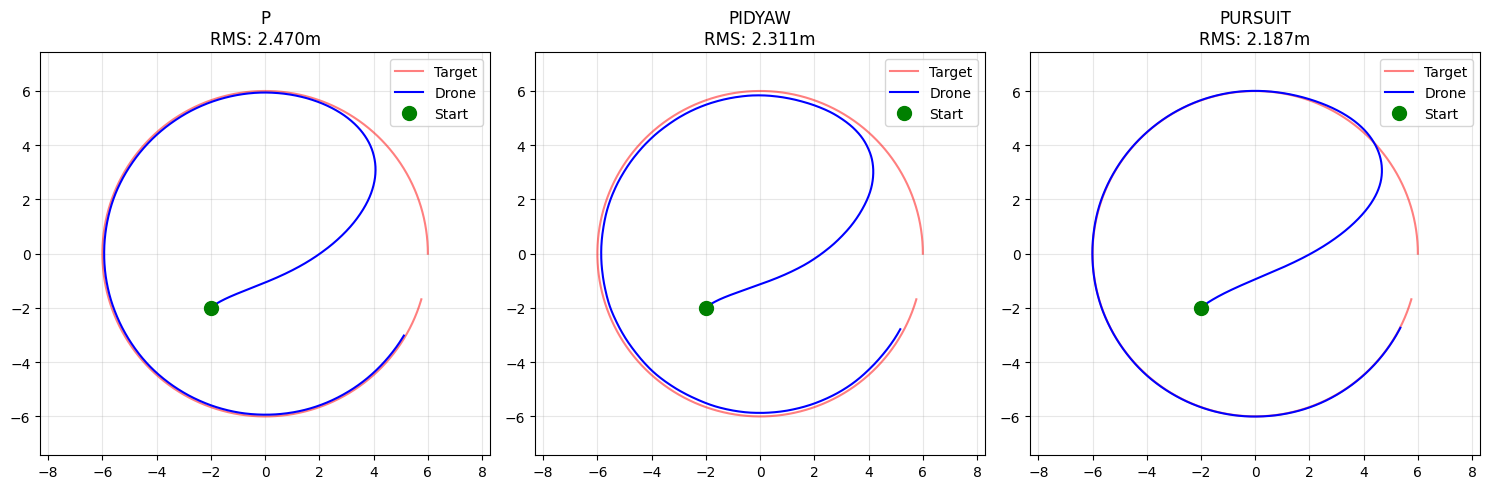

In [5]:
# Visual comparison of paths
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, res) in zip(axes, results.items()):
    ax.plot(res.target[:, 0], res.target[:, 1], 'r-', label='Target', alpha=0.5)
    ax.plot(res.drone[:, 0], res.drone[:, 1], 'b-', label='Drone')
    ax.plot(res.drone[0, 0], res.drone[0, 1], 'go', markersize=10, label='Start')
    ax.set_title(f"{name.upper()}\nRMS: {res.metrics.rms_dist:.3f}m")
    ax.axis('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

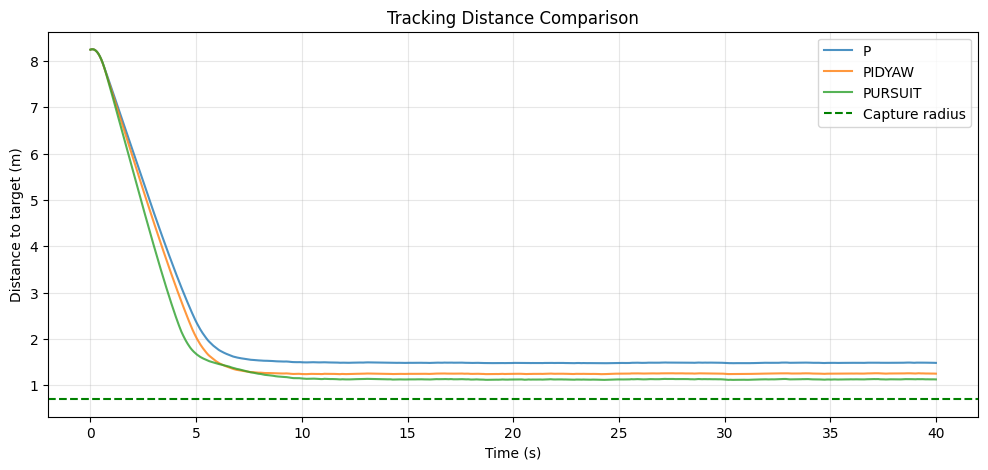

In [6]:
# Compare distance tracking over time
fig, ax = plt.subplots(figsize=(12, 5))

for name, res in results.items():
    ax.plot(res.t, res.dist, label=name.upper(), alpha=0.8)

ax.axhline(0.7, color='green', linestyle='--', label='Capture radius')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Distance to target (m)')
ax.set_title('Tracking Distance Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---
## 3️⃣ Experiment: Controller Tuning

Let's see how changing controller gains affects performance.

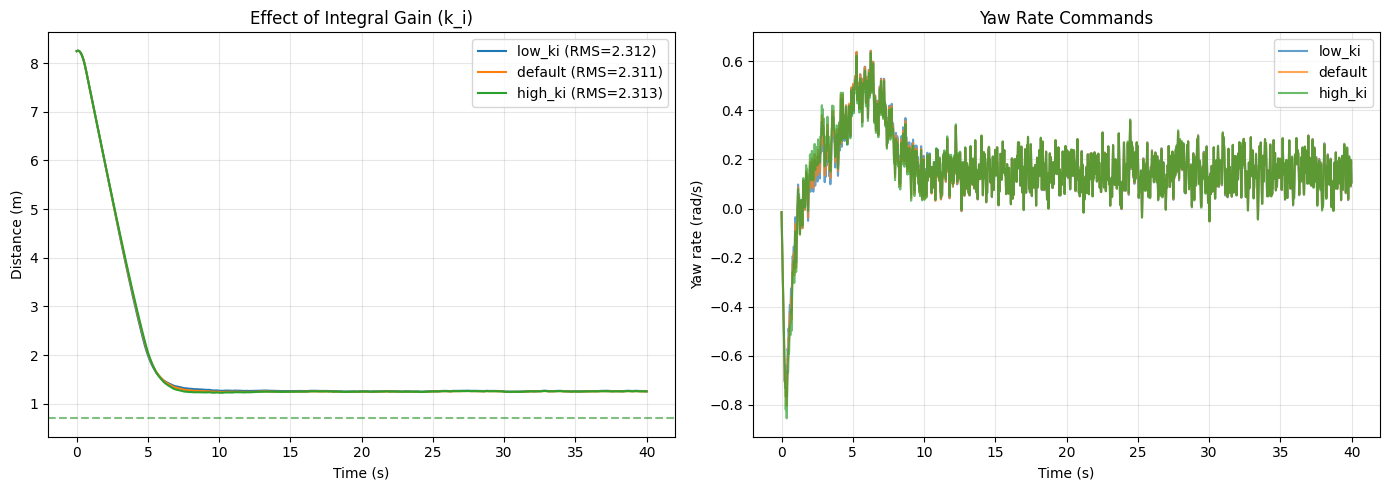

In [7]:
# Create PID controllers with different gains
pid_variants = {
    "low_ki": sim.run(controller="pidyaw", scenario="circle", k_i=0.1),
    "default": sim.run(controller="pidyaw", scenario="circle"),
    "high_ki": sim.run(controller="pidyaw", scenario="circle", k_i=0.8),
}

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance over time
for name, res in pid_variants.items():
    axes[0].plot(res.t, res.dist, label=f"{name} (RMS={res.metrics.rms_dist:.3f})")
axes[0].axhline(0.7, color='g', linestyle='--', alpha=0.5)
axes[0].set_title('Effect of Integral Gain (k_i)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Distance (m)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Yaw rate commands
for name, res in pid_variants.items():
    axes[1].plot(res.t, res.cmd_yaw, label=name, alpha=0.7)
axes[1].set_title('Yaw Rate Commands')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Yaw rate (rad/s)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 🎯 Your Turn: Tune the P Controller

Try changing `k_yaw` and `k_fwd` to see how they affect tracking.

RMS Distance: 2.470 m
Time to Capture: inf s


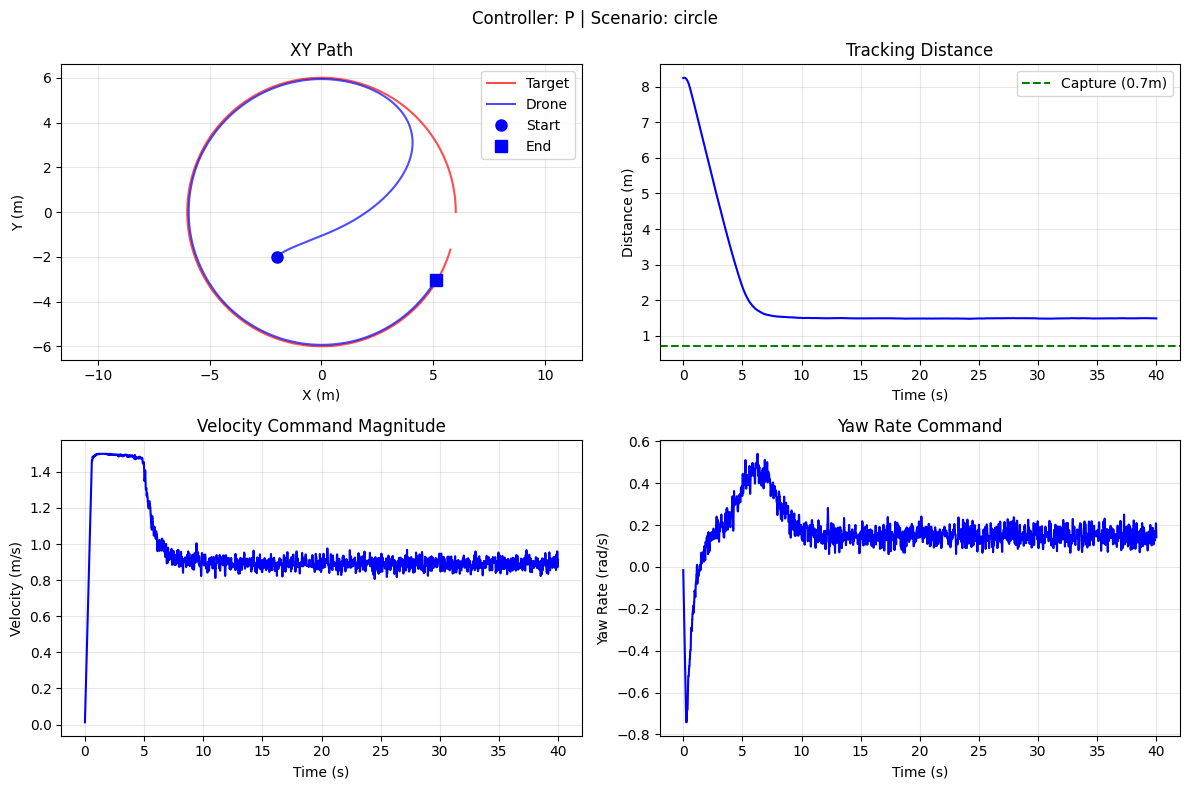

(<Figure size 1200x800 with 4 Axes>,
 array([[<Axes: title={'center': 'XY Path'}, xlabel='X (m)', ylabel='Y (m)'>,
         <Axes: title={'center': 'Tracking Distance'}, xlabel='Time (s)', ylabel='Distance (m)'>],
        [<Axes: title={'center': 'Velocity Command Magnitude'}, xlabel='Time (s)', ylabel='Velocity (m/s)'>,
         <Axes: title={'center': 'Yaw Rate Command'}, xlabel='Time (s)', ylabel='Yaw Rate (rad/s)'>]],
       dtype=object))

In [8]:
# TODO: Experiment with different k_yaw and k_fwd values
# Hint: Higher k_yaw = faster turning, Higher k_fwd = faster approach

my_result = sim.run(
    controller="p",
    scenario="circle",
    k_yaw=1.8,   # Try: 1.0, 2.0, 3.0
    k_fwd=0.6,   # Try: 0.3, 0.6, 1.0
)

print(f"RMS Distance: {my_result.metrics.rms_dist:.3f} m")
print(f"Time to Capture: {my_result.metrics.t_capture:.2f} s")

sim.plot(my_result)

---
## 4️⃣ Experiment: Effect of Noise

Real sensors aren't perfect. Let's see how noise affects tracking.

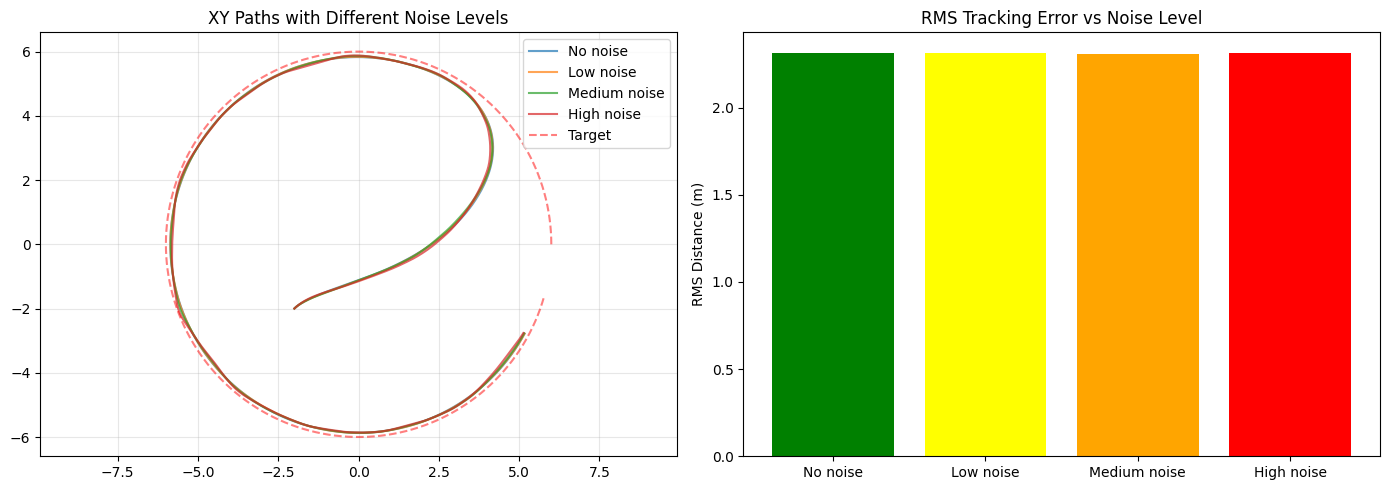

In [9]:
noise_levels = [
    ("No noise", 0.0, 0.0),
    ("Low noise", 0.02, 0.05),
    ("Medium noise", 0.05, 0.15),
    ("High noise", 0.1, 0.3),
]

noise_results = {}
for name, nb, nr in noise_levels:
    cfg = SimConfig(noise_bearing=nb, noise_range=nr)
    noise_results[name] = sim.run(
        controller="pidyaw", 
        scenario="circle",
        config=cfg,
    )

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Paths
for name, res in noise_results.items():
    axes[0].plot(res.drone[:, 0], res.drone[:, 1], label=name, alpha=0.7)
axes[0].plot(noise_results["No noise"].target[:, 0], 
             noise_results["No noise"].target[:, 1], 
             'r--', label='Target', alpha=0.5)
axes[0].set_title('XY Paths with Different Noise Levels')
axes[0].axis('equal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMS comparison
names = list(noise_results.keys())
rms_vals = [r.metrics.rms_dist for r in noise_results.values()]
axes[1].bar(names, rms_vals, color=['green', 'yellow', 'orange', 'red'])
axes[1].set_ylabel('RMS Distance (m)')
axes[1].set_title('RMS Tracking Error vs Noise Level')

plt.tight_layout()
plt.show()

---
## 5️⃣ Experiment: Different Scenarios

Try different target motion patterns.

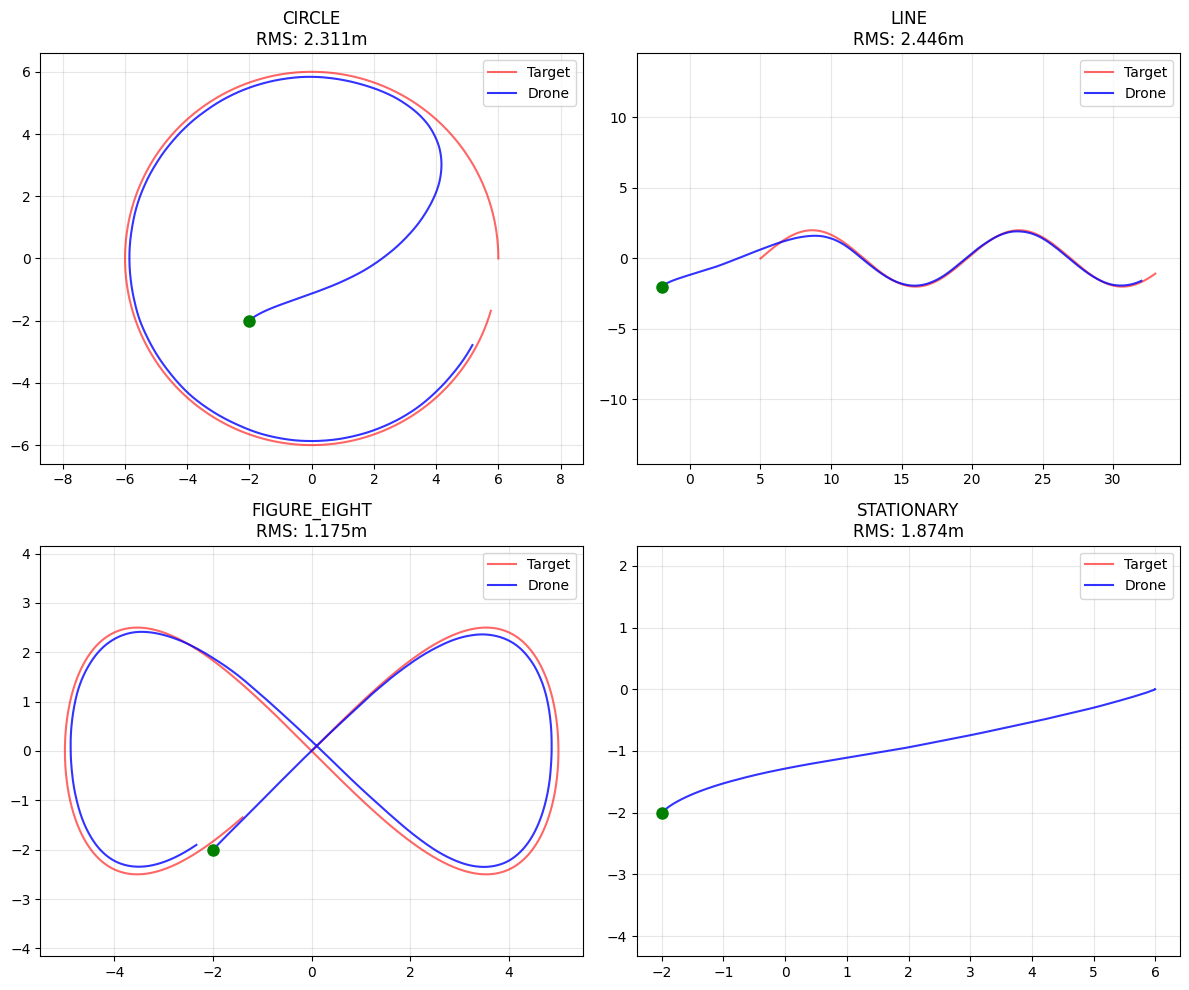

In [10]:
scenarios = ["circle", "line", "figure_eight", "stationary"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, scenario in zip(axes, scenarios):
    res = sim.run(controller="pidyaw", scenario=scenario)
    
    ax.plot(res.target[:, 0], res.target[:, 1], 'r-', label='Target', alpha=0.6)
    ax.plot(res.drone[:, 0], res.drone[:, 1], 'b-', label='Drone', alpha=0.8)
    ax.plot(res.drone[0, 0], res.drone[0, 1], 'go', markersize=8)
    ax.set_title(f'{scenario.upper()}\nRMS: {res.metrics.rms_dist:.3f}m')
    ax.axis('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

---
## 6️⃣ Experiment: FCU Limits

What happens when the drone has slower actuators?

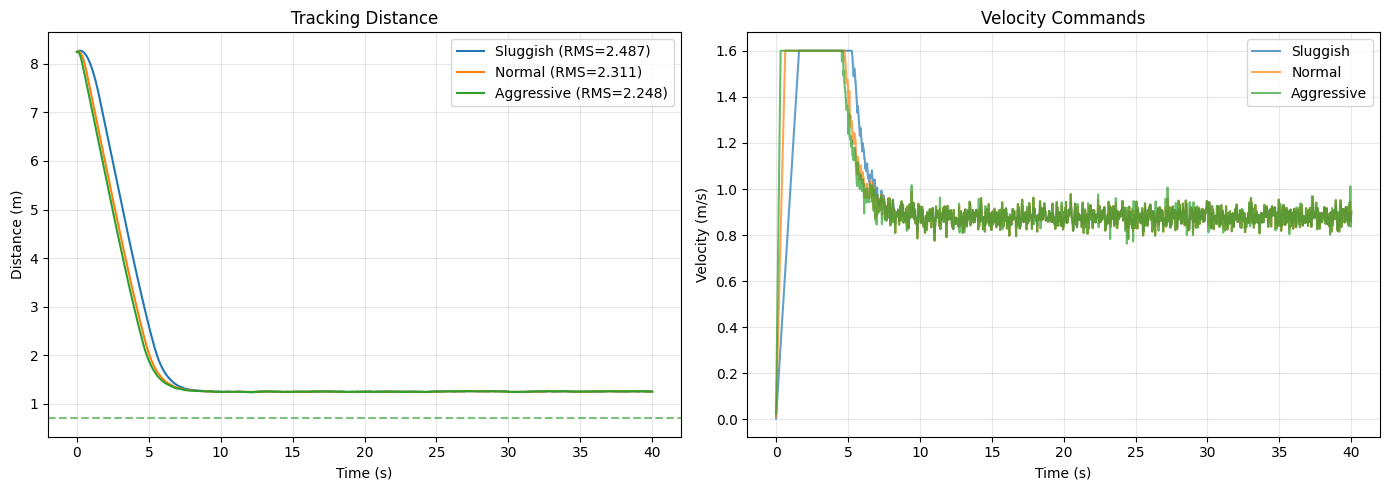

In [11]:
fcu_configs = [
    ("Sluggish", SimConfig(a_max=1.0, yaw_rate_max=0.8)),
    ("Normal", SimConfig(a_max=2.5, yaw_rate_max=1.5)),
    ("Aggressive", SimConfig(a_max=5.0, yaw_rate_max=3.0)),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, cfg in fcu_configs:
    res = sim.run(controller="pidyaw", scenario="circle", config=cfg)
    axes[0].plot(res.t, res.dist, label=f"{name} (RMS={res.metrics.rms_dist:.3f})")
    axes[1].plot(res.t, res.cmd_v, label=name, alpha=0.7)

axes[0].axhline(0.7, color='g', linestyle='--', alpha=0.5)
axes[0].set_title('Tracking Distance')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Distance (m)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Velocity Commands')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Velocity (m/s)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7️⃣ Challenge: Create Your Own Controller

Try implementing a custom controller!

Your controller's RMS distance: 2.113 m
Time to capture: inf s


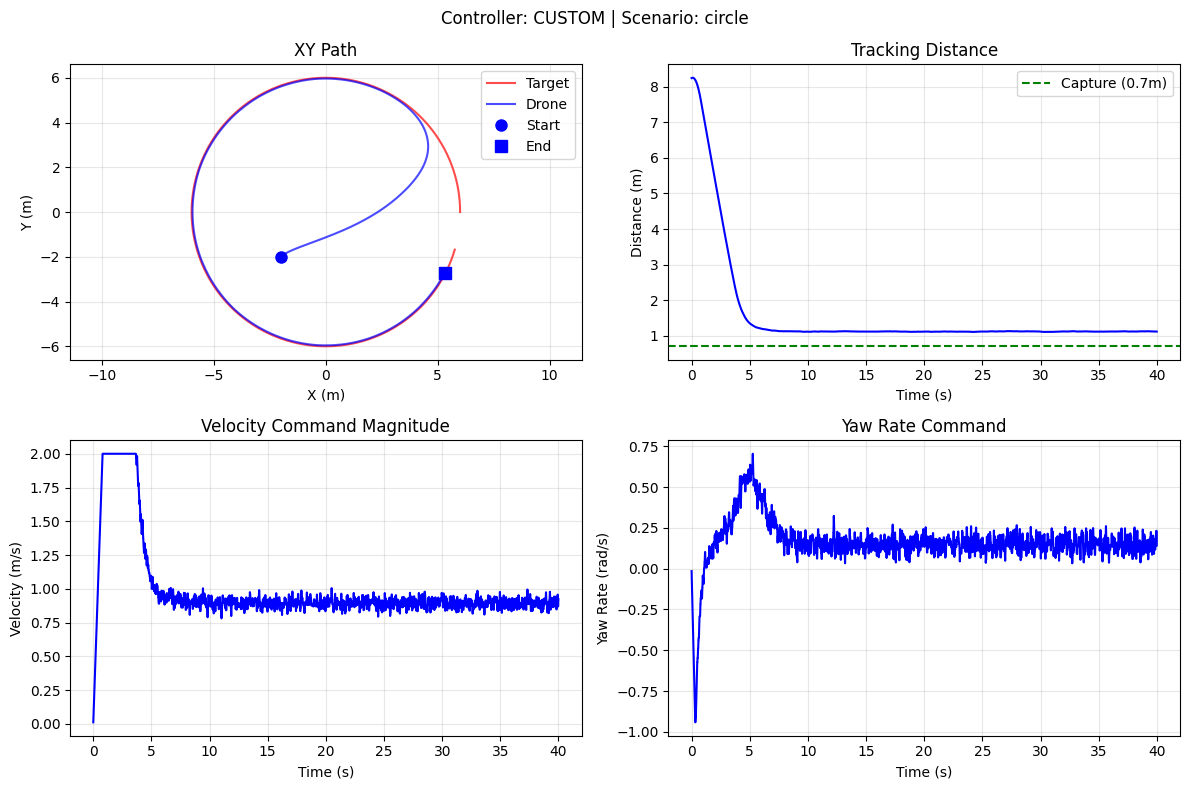

(<Figure size 1200x800 with 4 Axes>,
 array([[<Axes: title={'center': 'XY Path'}, xlabel='X (m)', ylabel='Y (m)'>,
         <Axes: title={'center': 'Tracking Distance'}, xlabel='Time (s)', ylabel='Distance (m)'>],
        [<Axes: title={'center': 'Velocity Command Magnitude'}, xlabel='Time (s)', ylabel='Velocity (m/s)'>,
         <Axes: title={'center': 'Yaw Rate Command'}, xlabel='Time (s)', ylabel='Yaw Rate (rad/s)'>]],
       dtype=object))

In [12]:
from drone_tracker import ControllerBase, CmdVel, Perception, wrap_pi
from dataclasses import dataclass

@dataclass
class MyCustomController(ControllerBase):
    """My custom controller - try modifying this!"""
    
    name: str = "Custom"
    
    # Add your gains here
    k_yaw: float = 2.0
    k_fwd: float = 0.7
    
    def step(self, p: Perception, dt: float) -> CmdVel:
        if not p.valid:
            return CmdVel(0.0, 0.0, 0.0)
        
        bearing = wrap_pi(p.bearing_err)
        
        # Your control logic here!
        # -------------------------
        
        # Simple example: P control with cosine speed reduction
        yaw_rate = self.k_yaw * bearing
        v_fwd = self.k_fwd * p.range_m * max(np.cos(bearing), 0.0)
        
        # -------------------------
        
        return CmdVel(float(v_fwd), 0.0, float(yaw_rate))


# Test your controller
my_ctrl = MyCustomController(k_yaw=2.5, k_fwd=0.8)
result = sim.run(controller=my_ctrl, scenario="circle")

print(f"Your controller's RMS distance: {result.metrics.rms_dist:.3f} m")
print(f"Time to capture: {result.metrics.t_capture:.2f} s")

sim.plot(result)

---
## 📚 Quick Reference

### Controllers
- `"p"` - Simple proportional control
- `"pidyaw"` - PID on yaw, P on velocity
- `"pursuit"` - Pursuit guidance style

### Scenarios
- `"circle"` - Circular motion (good for testing tracking)
- `"line"` - Linear motion with sine wave
- `"figure_eight"` - Figure-8 pattern
- `"stationary"` - Static target (convergence test)
- `"random"` - Random walk

### Key Parameters
```python
SimConfig(
    duration=40.0,      # Simulation time (s)
    ctrl_hz=30.0,       # Controller rate
    noise_bearing=0.02, # Sensor noise (rad)
    noise_range=0.05,   # Sensor noise (m)
    v_max=2.0,          # Max velocity (m/s)
    a_max=2.5,          # Max acceleration (m/s²)
)
```